# Capstone: Design and Evaluate a Smart Study Reminder Experiment
### Experimentation & Causal Inference — SDAIA Academy

## Business Question
Does sending smart study reminders improve students' study performance and task completion rates?

## Hypothesis
Students who receive smart study reminders will have higher study performance and completion rates than students who do not receive reminders.

## Experiment Design
- **Treatment group:** Students receive smart study reminders.
- **Control group:** Students do not receive smart study reminders.
- **Random assignment:** Students are randomly assigned to treatment and control groups.

## Primary Outcome
Study task completion rate.

## Secondary Outcome
Average study performance score.

## Expected Result
We expect the treatment group to have higher completion rates and better study performance than the control group.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [2]:
# Reproducible simulated experiment data
np.random.seed(42)
n = 200

student_id = np.arange(1, n + 1)
treatment = np.random.binomial(1, 0.5, n)

# Potential outcome-generating assumptions for the simulation
completion_probability = np.where(treatment == 1, 0.80, 0.60)
performance = np.where(
    treatment == 1,
    np.random.normal(80, 10, n),
    np.random.normal(70, 10, n)
)
completed = np.random.binomial(1, completion_probability)

data = pd.DataFrame({
    'student_id': student_id,
    'treatment': treatment,
    'completion_probability': completion_probability,
    'performance': performance,
    'completed': completed
})


## Preview of the Simulated Data


In [3]:
data.head()


,student_id,treatment,completion_probability,performance,completed
0,1,0,0.6,78.576596,1
1,2,1,0.8,82.322537,0
2,3,1,0.8,82.930725,1
3,4,1,0.8,72.856486,1
4,5,0,0.6,69.814869,1


## Group-Level Outcomes


In [4]:
group_summary = data.groupby('treatment')[['completed', 'performance']].mean()
group_summary


,completed,performance
treatment,,
0,0.696078,69.452995
1,0.785714,80.963246


## Average Treatment Effects


In [5]:
ate_completion = (
    data.loc[data['treatment'] == 1, 'completed'].mean()
    - data.loc[data['treatment'] == 0, 'completed'].mean()
)

ate_performance = (
    data.loc[data['treatment'] == 1, 'performance'].mean()
    - data.loc[data['treatment'] == 0, 'performance'].mean()
)

print(f"Average treatment effect on completion rate: {ate_completion:.3f} ({ate_completion * 100:.1f} percentage points)")
print(f"Average treatment effect on performance: {ate_performance:.2f} points")


Average treatment effect on completion rate: 0.090 (9.0 percentage points)
Average treatment effect on performance: 11.51 points


## Visualization


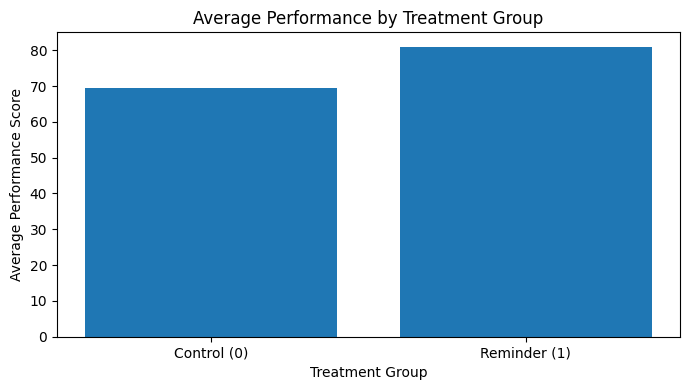

In [6]:
mean_performance = data.groupby('treatment')['performance'].mean()

plt.figure(figsize=(7, 4))
plt.bar(['Control (0)', 'Reminder (1)'], mean_performance.values)
plt.title('Average Performance by Treatment Group')
plt.xlabel('Treatment Group')
plt.ylabel('Average Performance Score')
plt.tight_layout()
plt.show()


## Conclusion
The treatment group achieved a higher task completion rate and better average performance than the control group in this simulated experiment.

- The estimated treatment effect on completion was approximately **9.0 percentage points**.
- The estimated treatment effect on performance was approximately **11.5 points**.

These results suggest that smart study reminders may improve student outcomes in the simulated setting. Because this notebook uses simulated data, the findings should be validated with a real randomized experiment before making a real-world causal claim.
